## 3.1 Forma matricial

A resolução de sistema lineares é provavelmente o processo numérico mais utilizado para simular situações do mundo real. É uma etapa fundamental na busca de soluções de problemas que envolvam, por exemplo, equações diferenciais parciais, otimização, regressão linear e não linear e conjuntos de equações não lineares. Geralmente, é a fase que demanda a maior parte do tempo de processamento para resolver o problema. Portanto, é de extrema importância que se tenha uma implementação eficiente do método. 

Nas seções seguintes, serão abordados os principais métodos diretos e alguns métodos iterativos usados na para a resolução de sistemas de equaçãoes algébricas lineares (ou simplesmente, sistemas lineares).

Considere a forma geral de um sistema linear de $n$ equações e $n$ incógnias

$$ \begin{cases} 
	         a_{11}x_1 +a_{12}x_2 + \cdots + a_{1n}x_n = b_1\\ 
	         a_{21}x_1 +a_{22}x_2 + \cdots + a_{2n}x_n = b_2\\
	         \vdots   \\
	         a_{n1}x_1 +a_{n2}x_2 + \cdots + a_{nn}x_n = b_n\\
             \end{cases} $$

O qual pode ser escrito em notação compacta, na seguinte forma

$$  \sum_{j=1}^{n} a_{ij} x_j = b_i, \quad i=1,2,\ldots,n$$

com $a_{ij}$ e $b_i$ sendo coeficientes reais conhecidos e $x_i$ as incógnitas. 

Este mesmo sistema pode também ser escrito na forma de uma equação matricial 

$$Ax=b$$

em que $A= [a_{ij}]$ com $i,j=1,\ldots,n$, é a matriz dos coeficientes, 
$x=[x_1,x_2,\ldots,x_n]^t$ é o vetor de incógintas e $b=[b_1, b_2,\ldots,b_n]^t$ é o vetor de termos independentes de  $x$. Então, tem-se

$$\left[\begin{array}{cccc} 
	         a_{11} & a_{12} & \cdots & a_{1n} \\ 
	         a_{21} & a_{22} & \cdots & a_{2n} \\
	         \vdots & \vdots & \vdots & \vdots \\
	         a_{n1} & a_{n2} & \cdots & a_{nn} \\
	         \end{array} \right]
\left[\begin{array}{c} 
	         x_1 \\ 
	         x_2 \\
             \vdots\\
	         x_n \\
	         \end{array} \right]
=
\left[\begin{array}{c} 
	         b_1 \\ 
	         b_2 \\
             \vdots\\
	         b_n \\
	         \end{array} \right]
	         $$

Resolver o sistema dado, consiste em encontrar o vetor solução $\overline x=[\overline x_1, \overline x_2,\ldots, \overline x_n]^t$ que satisfaça todas as equações simultaneamente. Uma condição suficiente para que este sistema possua solução única é que $\det(A) \neq 0$.

Como um primeiro exemplo vamos criar e realizar algumas operações básicas com vetores e matrizes usando a biblioteca `numpy` em Python. Para isso vamos utilizar a estrutura `array`, que é usada tanto para representar vetores quanto matrizes. Um vetor é representado por um `array` unidimensional e uma matriz por um `array` bidimensional. Para acessar os elementos em um `array` usamos índices (iniciando em zero) entre colcetes. Vejamos um exemplo.

In [1]:
import numpy as np
np.set_printoptions(precision = 4)

**Exemplo 3.1.1:** Dada a matriz 
$M= \left[\begin{array}{ccc} 
	         1 & 2  & 3 \\ 
	         -1 & 5 &  0 \\
	         7 & -2 &  4 \\
	         \end{array} \right]$
e o vetor $v = \left[ 
            \begin{array}{c} 
	          3 \\ 
	         -1  \\
	          0 \\
	         \end{array} \right]$
             
vamos escrevê-los como `array`'s e fazer as seguintes operações:

a) somar o 1º elemento de $v$ com o 2º elemento da terceira linha de $M$

b) escrever a 3ª linha de $M$ somada à 1ª multiplicada por $-7$

c) multiplicar $M$ por $v$

d) obter os produtos escalar e vetorial de $v$ por $u=[5,-1,4]^T$

e) calcular o módulo do vetor $v$

*Solução:* Para entrar com a matriz $M$ e o vetor $v$, primeiramente importamos a biblioteca `numpy` e então criamos os `array`'s. O produto entre matrizes pode ser obtido usando o operador `@` ou as funções `matmul` ou `dot` ([veja a documentação](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html)). O produto vetorial é feito usando a função `cross` ([veja a documentação](https://numpy.org/doc/stable/reference/generated/numpy.cross.html)).

In [2]:
M = np.array([[1,2,3],[-1,5,0],[7,-2,4]])
v = np.array([3,-1,0])

In [3]:
# solução letra a)
print('a)', v[0] + M[1,2])

# solução letra b)
print('b)',M[2] - 7*M[0])

# solução letra c)
print('c)',np.dot(M,v))

# solução letra d)
print('d)',np.dot(v,[5,-1,4]))
print('  ',np.cross(v,[5,-1,4]))

# solução letra e)
print('e)',np.sqrt(v.dot(v)))

a) 3
b) [  0 -16 -17]
c) [ 1 -8 23]
d) 16
   [ -4 -12   2]
e) 3.1622776601683795


**Atividade 3.1.1:** Dada a matriz  $
N= \left[\begin{array}{ccc} 
	         4 & -2  & 1 \\ 
	         0 & 3 &  5 \\
	         -1 & 6 &  2 \\
	         \end{array} \right]
$ e o vetor  $
w = \left[ 
            \begin{array}{c} 
	          -2 \\ 
	          4  \\
	          1 \\
	         \end{array} \right]
$
vamos escrevê-los como `array`'s e realizar as seguintes operações:

a)
Somar o 2º elemento de $w$ com o 3º elemento da primeira linha de $N$.

b)
Escrever a 2ª linha de $N$ somada à 3ª multiplicada por $3$.

c)
Multiplicar $N$ por $w$.

d)
Obter os produtos escalar e vetorial de $w$ por $z=[3,2,-1]^T$.

e)
Calcular o módulo do vetor $w$.

Observe que o sistema $N x=w$, em que $N$ e $w$ são a matriz e o vetor da atividade 3.1.1, possui solução única pois $\det(N) \neq 0$. 

In [4]:
N = np.array([[4,-2,1],[0,3,5],[-1,6,2]])
np.linalg.det(N)

-83.00000000000003

Além disso, observe que o vetor $x=[-0.90361446, -0.31325301,  0.98795181]^t$ é uma solução aproximada do sistema $N x=w$. Podemos vertificar multiplicando $N$ por $x$ e obter que o resultado é $w$ (salvo erro de aproximação).

In [5]:
w = np.array([-2,4,1])
x = np.array([-0.90361446, -0.31325301,  0.98795181])

In [6]:
N.dot(x)

array([-2.,  4.,  1.])

In [7]:
np.round(N.dot(x),7)

array([-2.,  4.,  1.])

### Interpretação gráfica

No caso de um sistema $2 \times 2$, graficamente, em $R^2$, a solução representa a intersecção das retas definidas pelas equações que compõe o sistema. Vejamos os exemplos a seguir.

**Exemplo 3.1.2:** Os sistemas lineares

(a) $\left\{\begin{array}{l}-x_1+2 x_2=3 \\ x_1+x_2=3\end{array}\right. , \qquad$
(b) $\left\{\begin{array}{l}x_1+x_2=1 \\ 2 x_1+2 x_2=2\end{array}\right. \qquad \text{e} \qquad$
(c) $\left\{\begin{array}{l}x_1+x_2=1 \\ 2 x_1+2 x_2=4\end{array}\right. $

são tais que: (a) tem como única solução $\bar{x}=(1,2)^t$, como pode ser visto no gráfico abaixo; (b) tem infinitas soluções já que as duas equações representam a retas coincidentes; e (c) não tem nenhuma solução (sistema inconsistente) já que as duas equações representam a retas paralelas.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

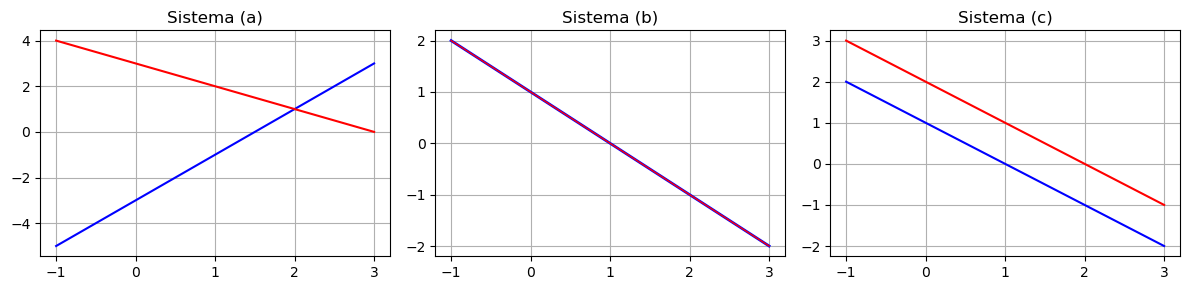

In [9]:
x = np.linspace(-1, 3, 2)

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

# Gráfico 1
axs[0].plot(x, -3 + 2*x, "b-")
axs[0].plot(x, 3 - x, "r-")
axs[0].grid(True)
axs[0].set_title("Sistema (a)")

# Gráfico 2
axs[1].plot(x, 1 - x, "b-", linewidth=2.0)
axs[1].plot(x, (2 - 2*x)/2, "r-", linewidth=1.0)
axs[1].grid(True)
axs[1].set_title("Sistema (b)")

# Gráfico 3
axs[2].plot(x, 1 - x, "b-")
axs[2].plot(x, (4 - 2*x)/2, "r-")
axs[2].grid(True)
axs[2].set_title("Sistema (c)")

plt.tight_layout()
plt.show()

Para sistema com três incógnitas, as equações envolvidas são geometricamente interpretadas como planos em $\mathbb R^3$. A figura abaixo mostra quatro possibilidades de posições relativas entre três planos distintos. 

![](https://github.com/tiagoburiol/metodos_numericos_em_python/blob/main/3_SISTEMAS_LINEARES/imagens/planos_interc.png?raw=true){width=1200px}

**Condicionamento de matrizes**

Sabemos que um sistema linear $n \times n$, $Ax=b$ tem solução única se $\det(A) \neq 0$, caso $\det(A)=0$ dizemos que a matriz $A$ é singular e o sistema poderá ter infinitas soluções ou nenhuma solução. Mas o que acontece se a matriz é "quase singular" ($\det(A)$ é muito pequeno)?

Dizemos que $\det(A)=|A|$ é muito pequeno se $|A|<<||A||$ onde $||A||$ é a **norma** da matriz $A$. A norma é um número real usado para expressar a magnitude de um vetor ou de uma matriz. 

### Norma de vetores e matrizes

No caso de um vetor $x$ de tamanho $n$, as normas são definidas em termos da _norma−p_

$$ \|x\|_p = \left( \sum^n_{i=1} \left|x_i \right|^p \right)^{1/p}, \,\,\, 1\leq p < \infty$$

A partir dessa equação, definimos três normas vetoriais importantes:

| Norma soma de magnitudes | Norma Euclidiana | Norma de máxima magnitude |
  |:---:|:---:|:---:|
  | $\|x\|_1 = \sum^n_{i=1} \left\|x_i \right\|$ | $\|x\|_2=\sqrt{\sum^n_{i=1}\left\|x_i  \right\|^2}$ | $\displaystyle\|x\|_\infty = \max_{1 \leq i\leq n} \left\|x_i \right\|$ |

Normas de matrizes podem ser definidas forma semelhante, considerando $\mathrm{A}=\left(a_{i j}\right)_{i, j=1, \ldots, n}$, então temos as seguintes normas de matrizes:

  | Norma Euclidiana | Norma linha | Norma coluna |
  |:---:|:---:|:---:|
  | $\displaystyle\|\mathbf{A}\|_2=\sqrt{\sum_{i=1}^{n}\sum_{j=1}^{n}(a_{ij})^2}$ |   $\displaystyle\|\mathbf{A}\|_{\infty}=\max_{1\leq i\le n}\sum_{j=1}^{n}\vert a_{ij}\vert$ |   $\displaystyle\|\mathbf{A}\|_{1}=\max_{1\le j\le n}\sum_{i=1}^{n}\vert a_{ij}\vert$ |


O **número de condicionamento da matriz** é uma medida formal definida como 

$$\text{cond}(A) = \|A\| \|A^{-1}\| $$

se esse número estiver próximo de 1, então a matriz é dita *bem condicionada*. Esse número aumenta com o mal condicionamento da matriz. 

Infelizmente, o número de condicionamento é computacionalmente oneroso para matrizes grandes. Então, muitas vezes é suficiente estimar o condicionamento comparando o determinante com a magnitude dos elementos da matriz. 

Se as equações estiverem mal condicionadas, pequenas mudanças nos coeficientes da matriz resultarão em grandes mudanças na solução.

**Exemplo 3.1.3:**
Consideremos o sistema linear 

$$\begin{cases} 
	         2x_1 + x_2 = 3\\ 
             2x_1 + 1.001x_2 = 0
             \end{cases}$$
             
Cuja solução é dada por:

In [10]:
import scipy.linalg as la

A = [[2, 1], [2, 1.001]]
b = [3, 0]
print ('x =', la.solve(A,b))

x = [ 1501.5 -3000. ]


A matriz dos coeficientes desse sistema tem um número de condicionamento grande, ou seja, a matriz é mal condicionada

In [11]:
print (la.norm(A) * la.norm(la.inv(A)))

5001.000500000551


In [12]:
la.norm(A)

3.162594030222659

In [13]:
la.det(A)

0.0019999999999997797

Observe o que acontece com a solução do sistema quando variamos ligeiramente um dos coeficientes 

In [14]:
A = [[2, 1], [2, 1.002]]
print ('x =',la.solve(A,b))

x = [  751.5 -1500. ]


Uma mudança no coeficiente na ordem de 1% gerou uma diferença na solução de 100%!

### Mais operações com matrizes

A seguir vamos ampliar nosso repertório de funções e operadores para criar, manipular e realizar cálculos com vetores e matrizes usando `numpy`.  Lembrando que os índices dos *arrays* iniciam em $0$, então uma matriz em Python tem uma forma geral como a matriz $A =[a_{ij}]$, $i=0,\ldots,n$ e $j=0,\ldots,m$ representada abaixo. 

$$A = \begin{bmatrix}
a_{00} & a_{01} & \cdots & a_{0m} \\
a_{10} & a_{11} & \cdots & a_{1m} \\
\vdots & \vdots & \ddots & \vdots \\
a_{n0} & a_{n1} & \cdots & a_{nm}
\end{bmatrix}$$


Algumas operações úteis incluem tomar uma linha ou uma coluna de uma matriz, multiplicar uma matriz ou vetor por um número real não nulo, somar duas matrizes ou vetores, extrair a diagonal, etc. Vamos ver alguns exemplos:

**Exemplo 3.1.4:** Seja as matrizes

$$ A = \left[\begin{array}{ccc} 
	         1 & 2  & 3 \\ 
	         -1 & 5 &  0 \\
	         7 & -2 &  4 \\
	         \end{array} \right]  \quad \text{e} \quad
B = \left[\begin{array}{ccc} 
	         0 & -2  & 1 \\ 
	         1 & 0 &  5 \\
	         1 & -2 &  2 \\
	         \end{array} \right]$$

vamos fazer algumas operações:

In [15]:
# definindo uma matriz A
A = np.array([[1,2,3],[-1,5,0],[7,-2,4]])
print(A)

[[ 1  2  3]
 [-1  5  0]
 [ 7 -2  4]]


In [16]:
# definindo uma matriz B
B = np.array([[0,-2,1],[1,0,5],[1,-2,2]])
print(B)

[[ 0 -2  1]
 [ 1  0  5]
 [ 1 -2  2]]


In [17]:
# somando A e B
A+B

array([[ 1,  0,  4],
       [ 0,  5,  5],
       [ 8, -4,  6]])

In [18]:
# multiplicando A por B
A@B

array([[  5,  -8,  17],
       [  5,   2,  24],
       [  2, -22,   5]])

In [19]:
# ou 
A.dot(B)

array([[  5,  -8,  17],
       [  5,   2,  24],
       [  2, -22,   5]])

É fácil extrair uma linha da matriz, sua diagonal, obter sua transposta ou uma combinação linear. Veja os exemplos a seguir:

In [20]:
# pegando a segunda linha de A
A[1]

array([-1,  5,  0])

In [21]:
# pegando a diagonal de A
np.diag(A)

array([1, 5, 4])

In [22]:
# transpondo
A.T

array([[ 1, -1,  7],
       [ 2,  5, -2],
       [ 3,  0,  4]])

In [23]:
# combinação linear
2*A-3*B

array([[  2,  10,   3],
       [ -5,  10, -15],
       [ 11,   2,   2]])

In [24]:
# combinação linear usando linhas da matriz A
2*A[0]-3*A[1]

array([  5, -11,   6])

### Sistemas triangulares e escalonamento de matrizes

Muitas vezes é útil escalonar a matriz ampliada de um sistema linear para obter um sistema triangular equivalente que seja mais fácil de resolver. Sistemas triagulares, em geral podem ser facilmente resolvidos por substituições sucessivas.

Um **sistema triangular inferior** representado por $Lx=b$, possui matriz de coeficientes tal que $[l_{ij}]=0$ para $i<j$, com $i,j=0,1,\ldots,n$. 

Um algoritmo para obter a sua solução é dado por:

$$ x_1 = b_1/a_{11}$$

para $i=2,3\ldots,n$, faça

$$ x_i = \frac{b_i- \sum\limits_{j=1}^{(i-1)} a_{ij}x_j}{a_{ii}}$$	         
	         
Usando Python, um código que implementa esse algoritmo, é mostrado no exemplo abaixo.

**Exemplo 3.1.5:** 

Seja o sistema linear

$$\begin{cases} 
	         2x_1 = 2\\ 
             x_1 + 4x_2 = -3\\
             x_1 + x_2 + x_3 = 0
             \end{cases}$$
             
um código em Python que implementa esse algoritmo e a solução obtida executando o programa são mostrados a seguir 

In [25]:
A = np.array([[2,0,0],
              [1.,4.,0],
              [1.,1.,1.]])

b = np.array([2.,-3., 0])

M = np.hstack((A,b.reshape(3,1)))
M

array([[ 2.,  0.,  0.,  2.],
       [ 1.,  4.,  0., -3.],
       [ 1.,  1.,  1.,  0.]])

In [26]:
x1 = b[0]/A[0][0]
x = [x1]

for i in range(1,len(A)):
    soma = 0
    for j in range(0,i):
        soma +=  A[i][j]*x[j]
    x.append((b[i]-soma)/A[i][i])
print (x)

[1.0, -1.0, 0.0]


In [27]:
A@x

array([ 2., -3.,  0.])

Uma versão mais elegante do algoritmo para resolução de um sistema triangular inferior pode ser escrito como é mostrado abaixo

In [28]:
for i in range(len(b)): 
    b[i] = (b[i] - np.dot(A[i,0:i],b[0:i]))/A[i][i] 
print (b)

[ 1. -1.  0.]


Um **sistema triangular superior** representado por $Ux=b$, possui matriz de coeficientes tal que $[u_{ij}]=0$ para $i>j$, com $i,j=0,1,\ldots,n$. 

Um algoritmo para obter a sua solução é dado por:

$$ x_n = b_n/a_{nn}$$

para $i=(n-1), (n-2),\ldots,1$, faça

$$ x_i = \frac{b_i- \sum\limits_{j=i+1}^{(n)} a_{ij}x_j}{a_{ii}}$$	

Usando Python, um código que implementa esse algoritmo, é mostrado abaixo.

In [29]:
def solve_U(U,b):
    n=len(b)
    x = np.empty(n)
    for i in range(n-1, -1, -1):
        x[i] = (b[i] - np.sum(U[i,i+1:n+1]*x[i+1:n+1]))/U[i,i]
    return x

**Exemplo 3.1.6:**
Seja o sistema linear

$$\begin{cases} 
	         3x_1 + x_2 +x_3= 4\\ 
             2x_2 -x_3 = 2\\
             3x_3 = 3
             \end{cases}$$
             
um código em Python que implementa esse algoritmo e a solução obtida executando o programa são mostrados a seguir 

In [30]:
A = np.array([[3,1,1],
              [0,2,-1],
              [0,0,3]]).astype(float)

b = np.array([4,2,3]).astype(float)

In [31]:
solve_U(A,b)

array([0.5, 1.5, 1. ])

In [32]:
x = np.linalg.solve(A,b)
x

array([0.5, 1.5, 1. ])

In [33]:
A@x

array([4., 2., 3.])

### Escalonamento de matrizes e resolução por eliminação de Gauss

O método de eliminação de Gauss para resolução de sistemas lineares consiste no processo 
de transformar um sistema $Ax=b$ em um sistema triangular equivalente, 
aplicando operações elementares sobre as linhas da matriz aumentada $[A \mid b]$. O sistema equivalente obtido ao final do processo, deve ser de resolução mais simples ou imediata, por substituição subsequente. 

O processo de eliminação de Gauss com pivoteamento diagonal consiste em tomar, a cada passo, como pivô,
os elementos da diadonal de $A$, desde que não seja nulo. Caso o algum elemento da diagonal seja nulo podemos permutar duas linhas da matriz a fim obter um pivô diferente de zero.

Para cada passo $k$ do processo, anulamos os termos abaixo do 
elemento da diagonal $a_{kk}$, subtraindo cada linha $i=k+1$ da matriz $[A \mid b]$, 
pela linha linha anterior, $i=k$, multiplicada pelo fator $m_{ik}=\frac{a_{ik}}{a_{kk}}$.

Assim, no 1º passo ($k=1$), fazemos $m_{i1}=\frac{a_{i1}}{a_{k1}}$, $i=2,\ldots,n$ 
e cada linha de $[A \mid b]$, a partir da 2ª, será subtraída da 1ª linha multiplicada por
$m_{k1}$ obtendo-se a matriz $[A^{(1)} \mid b^{(1)}]$ tal que

$$[A^{(1)} \mid b^{(1)}] = \left[\begin{array}{ccccccc} 
	         a^{(1)}_{11} & a^{(1)}_{12} & a^{(1)}_{13} & \cdots & a^{(1)}_{1n} & | & b^{(1)}_1\\ 
	         0            & a^{(2)}_{22} & a^{(2)}_{23} & \cdots & a^{(2)}_{2n} & | & b^{(2)}_2\\
	         0            & a^{(2)}_{32} & a^{(2)}_{33} & \cdots & a^{(2)}_{3n} & | & b^{(2)}_3\\
	         \vdots       & \vdots       & \vdots       & \vdots & \vdots       & | & \vdots   \\
	         0            & a^{(2)}_{n2} & a^{(2)}_{n3} & \cdots & a^{(2)}_{nn} & | & b^{(2)}_n\\
	         \end{array} \right]$$
             

No 2º passo ($k=2$), fazemos $m_{i2}=\frac{a_{i2}}{a_{k2}}$, $i=3,\ldots,n$ 
e cada linha de $[A^{(1)} \mid b^{(1)}]$, a partir da 3ª, será subtraída da 2ª linha multiplicada por
$m_{k2}$ obtendo-se a matriz $[A^{(2)} \mid b^{(2)}]$ tal que

$$[A^{(2)} \mid b^{(2)}] = \left[\begin{array}{ccccccc} 
	         a^{(1)}_{11} & a^{(1)}_{12} & a^{(1)}_{13} & \cdots & a^{(1)}_{1n} & | & b^{(1)}_1\\ 
	         0            & 0            & a^{(2)}_{23} & \cdots & a^{(2)}_{2n} & | & b^{(2)}_2\\
	         0            & 0            & a^{(3)}_{33} & \cdots & a^{(3)}_{3n} & | & b^{(3)}_3\\
	         \vdots       & \vdots       & \vdots       & \vdots & \vdots       & | & \vdots   \\
	         0            & 0            & a^{(3)}_{n3} & \cdots & a^{(3)}_{nn} & | & b^{(3)}_n\\
	         \end{array} \right]$$

Segundo os passos seguintes, até o passo $n-1$, obtemos ou sistema triangular superior na forma   
 
$$ \begin{cases} 
	         a^{(1)}_{11}x_1 + a^{(1)}_{12}x_2 + a^{(1)}_{13}x_2 + \cdots + a^{(1)}_{1n}x_n = b^{(1)}_1\\ 
             \hspace{65pt}     a^{(2)}_{22}x_2 + a^{(2)}_{23}x_2 + \cdots + a^{(2)}_{2n}x_n = b^{(2)}_2\\ 
             \hspace{65pt}     \hspace{65pt}     a^{(3)}_{33}x_2 + \cdots + a^{(3)}_{3n}x_n = b^{(3)}_3\\ 
 	         \hspace{65pt}     \hspace{65pt}      \hspace{65pt}     \hspace{45pt}      \vdots   \\
	         \hspace{65pt}     \hspace{65pt}      \hspace{65pt}     \hspace{45pt}  a^{(n)}_{nn}x_n = b^{(n)}_n\\ 
	         \end{cases} $$

O qual pode ser resolvido por substituição retroativa.



**Exemplo 3.1.7:** 
Usando o método de eliminação de Gauss, resolva o sistema de equações lineares:

$$
\left[\begin{array}{rrr}
3 & 0 & 1 \\
3 & 2 & 1 \\
-3 & 1 & 3
\end{array}\right]\left[\begin{array}{l}
x_1 \\
x_2 \\
x_3
\end{array}\right]=\left[\begin{array}{l}
1 \\
1 \\
3
\end{array}\right]
$$

Um exemplo de algoritmo para resolver sistemas lineares por eliminação de Gauss (sem pivoteamento e sem verificar valores nulos na diagonal).

In [34]:
# funcao que triangulariza o sistema
def escalona(M):
    n = len(M)
    for j in range(n-1):
        for i in range(j,n-1):            
            m = M[i+1,j]/M[j,j]
            M[i+1] = M[i+1]-m*M[j]
    return (M)

In [35]:
A = np.array([[3.,0.,1.],
              [3.,2.,1.],
              [-3.,1.,3.]])
b = np.array([1.,1.,3.])

In [36]:
M = np.hstack((A,b.reshape(3,1)))
M

array([[ 3.,  0.,  1.,  1.],
       [ 3.,  2.,  1.,  1.],
       [-3.,  1.,  3.,  3.]])

In [37]:
Mesc = escalona(M)
Mesc

array([[3., 0., 1., 1.],
       [0., 2., 0., 0.],
       [0., 0., 4., 4.]])

In [38]:
Aesc =  Mesc[:,:-1]
Aesc

array([[3., 0., 1.],
       [0., 2., 0.],
       [0., 0., 4.]])

In [39]:
besc = Mesc[:,-1]
besc

array([1., 0., 4.])

In [40]:
x = solve_U(Aesc, besc)
x

array([0., 0., 1.])

**Exemplo 3.1.8:** Represente o sistema linear

$$\begin{aligned}
x_1-x_2+2 x_3-x_4 & =-8, \\
2 x_1-2 x_2+3 x_3-3 x_4 & =-20, \\
x_1+x_2+x_3 & =-2, \\
x_1-x_2+4 x_3+3 x_4 & =4 .
\end{aligned}$$

e use a eliminação de Gauss para encontrar sua solução. 

In [41]:
A = np.array([[1,-1,2,-1],
              [2,-2,3,-3],
              [1,1,1,0],
              [1,-1,4,3]]).astype(float)
b = np.array([-8, -20, -2, 4])

M = np.hstack((A,b.reshape(4,1)))
print (M)

[[  1.  -1.   2.  -1.  -8.]
 [  2.  -2.   3.  -3. -20.]
 [  1.   1.   1.   0.  -2.]
 [  1.  -1.   4.   3.   4.]]


In [42]:
Mesc = escalona(M)

/tmp/ipykernel_109242/3041863753.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  m = M[i+1,j]/M[j,j]
/tmp/ipykernel_109242/3041863753.py:7: RuntimeWarning: invalid value encountered in multiply
  M[i+1] = M[i+1]-m*M[j]
/tmp/ipykernel_109242/3041863753.py:6: RuntimeWarning: invalid value encountered in scalar divide
  m = M[i+1,j]/M[j,j]


Observe que aqui ocorreu um problema de divisão por zero. Vamos modificar o código da eliminação de gaus e incluir o pivoteamento. Para isso vamos usar a função `np.argsort` que devolve os índices dos elementos uma coluna ordenados. Vejamos um exemplo:

In [43]:
M = np.hstack((A,b.reshape(4,1)))

In [44]:
# ordem crescente dos elementos da 3ª coluna (em valor absoluto) 
idx = np.argsort(abs(M[:,2]))

In [45]:
# trocando linhas para deixar a 3ª coluna em ordem decrescente
M = M[np.flip(idx)]
M

array([[  1.,  -1.,   4.,   3.,   4.],
       [  2.,  -2.,   3.,  -3., -20.],
       [  1.,  -1.,   2.,  -1.,  -8.],
       [  1.,   1.,   1.,   0.,  -2.]])

Agora vamos usar esse procedimento para incluir o pivoteamento na eliminação de Gauss.

In [46]:
M = np.hstack((A,b.reshape(4,1)))

In [47]:
def escalonap(M):
    n = len(M)
    for j in range(n-1):
        
        # pivoteamento
        m = M[j:,j:]
        idx=np.flip(np.argsort(abs(m[:,0])))
        M[j:,j:] = m[idx]
        
        for i in range(j,n-1):
            m = M[i+1,j]/M[j,j]
            M[i+1] = M[i+1]-m*M[j]
            
    return (M)

In [48]:
Mesc = escalonap(M)
Mesc

array([[  2. ,  -2. ,   3. ,  -3. , -20. ],
       [  0. ,   2. ,  -0.5,   1.5,   8. ],
       [  0. ,   0. ,   2.5,   4.5,  14. ],
       [  0. ,   0. ,   0. ,  -0.4,  -0.8]])

In [49]:
x = solve_U(Mesc[:,:-1], Mesc[:,-1])
x

array([-7.,  3.,  2.,  2.])

In [50]:
# checando se a solução está correta
np.allclose(np.dot(A, x), b)

True

Observe que, em um sistema 

$$Ax=b,$$ 

a matriz de coeficientes $A$ é **quadrada** se e somente se **o número de equações do sistema é igual ao número de incógnitas**.

Algumas matrizes quadradas são **invertíveis**. Isto é, se $A$ é uma matriz quadrada $n\times n$, pode existir outra matriz de mesmo ordem, denotada por $A^{-1}$, tal que

$$
AA^{-1} = A^{-1}A = I,
$$
onde $I$ é a matriz identidade de ordem $n$.

No caso específico em que $A$ é quadrada, vale que o sistema $Ax=b$ tem **solução única** se e somente se **$A$ é invertível**. 

Isso vale pois nesses casos podemos isolar o vetor $x$ multiplicando ambos os lados da equação matricial pela inversa $A^{-1}$:

$$
Ax=b\quad \implies\quad A^{-1}Ax=A^{-1}b\quad \implies\quad x = A^{-1}b.
$$

Ou seja, nesse caso, $x$ fica unicamente definido por $x = A^{-1}b$.

### Exercícios

---

> **1.** Use a eliminação de Gauss para resolver os seguintes sistemas lineares. Não reordene as equações. (A solução exata para cada sistema é  $\left( x_1=1, x_2=-1, x_3=3 \right)$.
>
>$$
 \begin{gathered}
 4 x_1-x_2+x_3=8, \\
 2 x_1+5 x_2+2 x_3=3, \\
 x_1+2 x_2+4 x_3=11 .
 \end{gathered}
 \quad \text{e} \quad
 \begin{aligned}
 4 x_1+x_2+2 x_3 & =9, \\
 2 x_1+4 x_2-x_3 & =-5, \\
 x_1+x_2-3 x_3 & =-9 .
 \end{aligned}
 $$

---

> **2.** Dada a matriz
> $M= \left[\begin{array}{ccc}
 	         1 & 2  & 3 \\
 	         -1 & 5 &  0 \\
 	         7 & -2 &  4 \\
 	         \end{array} \right]$
> e o vetor $v = \left[
             \begin{array}{c}
 	          3 \\
 	         -1  \\
 	          0 \\
 	         \end{array} \right]$
>
> defina os *arrays* para a matriz e o vetor e faça as seguintes operações:
>
> a) somar o 1º elemento de $v$ com o 2º elemento da terceira linha de $M$
>
> b) escrever a 3ª linha de $M$ somada à 1ª multiplicada por $-7$
>
> c) multiplicar $M$ por $v$
>
> d) obter os produtos escalar e vetorial de $v$ por $u=[5,-1,4]^T$
>
> e) calcular o módulo (norma Euclidiana) do vetor $v$
>
> f) escalonar a matriz $M$

---

> **3.** Considere o sistema linear
>
> $$\begin{cases}
     x_1 + 3x_2 -2x_3 = -22\\
     2x_1 -x_2 + 3x_3 = -9\\
     -2x_2 + 4x_3= -2
 \end{cases}. $$
>
> (a) Defina a matriz de coeficientes $A$ e o vetor de termos independentes $b$ como *arrays* e verifique que $x = \begin{bmatrix}x_1\\x_2\\x_3\end{bmatrix}= \begin{bmatrix}-1\\-11\\-6\end{bmatrix}$ é uma solução do sistema.
> >
> (b) Verifique que $A^{-1}=\begin{bmatrix}-\frac17& \frac47&-\frac12\\ \frac47&-\frac27&\frac12\\ \frac27&-\frac17&\frac12\end{bmatrix}$.

> **4.** Dado o sistema
>
> $$\begin{cases}
    -2x_1 + x_2 +3x_3 = 2\\
      x_1 -3 x_2 -x_3 = -3\\
     -x_1 - 2x_2 +2x_3= -1
 \end{cases}, $$
> mostre que $\begin{bmatrix}1\\1 \\1 \end{bmatrix}$ e $\begin{bmatrix}-7\\0 \\-4 \end{bmatrix}$ pertencem ao conjunto solução.

---

> **5.** Verifique se o sistema linear
> 
>$$ \begin{aligned}
 x_1+x_2-x_3+x_4-x_5 & =2, \\
 2 x_1+2 x_2+x_3-x_4+x_5 & =4, \\
 3 x_1+x_2-3 x_3-2 x_4+3 x_5 & =8, \\
 4 x_1+x_2-x_3+4 x_4-5 x_5 & =16, \\
 16 x_1-x_2+x_3-x_4-x_5 & =32 .
 \end{aligned}$$
> 
>
> possui solução única calculando o determinante da matriz dos coeficientes. Então obtenha a mariz inversa e encontre a solução fazendo $x = A^{-1}b$. Por fim, verifique a solução obtida comparando o produto $Ax$ com o vetor $b$.

---

> **6.** Resolva o sistema linear
> 
> $$
 \begin{aligned}
 x_1+x_2-x_3+x_4-x_5 & =2, \\
 2 x_1+2 x_2+x_3-x_4+x_5 & =4, \\
 3 x_1+x_2-3 x_3-2 x_4+3 x_5 & =8, \\
 4 x_1+x_2-x_3+4 x_4-5 x_5 & =16, \\
 16 x_1-x_2+x_3-x_4-x_5 & =32 .
 \end{aligned}$$

---